In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FYP_IIT/Clustering_ready_dataset.csv', encoding='latin1')
df.head()

,F1,F2,F3,F4,gender,marital_status,academic_year,academic_failure,age_group,degree_program,faculty_environment,home_environment
0,3.333333,4.000000,3.00,2.5,Female,Single,Year 4,Never,22-23,B.B.A. (Hons) in Business Economics,Satisfied,Yes
1,3.000000,3.666667,2.75,2.0,Female,Single,Year 4,Never,22-23,B.B.A. (Hons) in International Business,Satisfied,Yes
2,3.500000,2.000000,2.00,2.0,Female,Single,Year 4,Never,22-23,B.B.A. (Hons) in Human Resource Management,Very satisfied,Yes
3,3.000000,3.000000,2.50,3.0,Male,Single,Year 4,Once or twice,22-23,B.B.A. (Hons) in Business Economics,Satisfied,Yes
4,3.833333,4.333333,1.50,4.0,Male,Single,Year 4,Never,22-23,B.B.A. (Hons) in Business Economics,Satisfied,Yes


In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select only stress dimensions
X = df[['F1', 'F2', 'F3', 'F4']]

# Standardize (VERY IMPORTANT for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

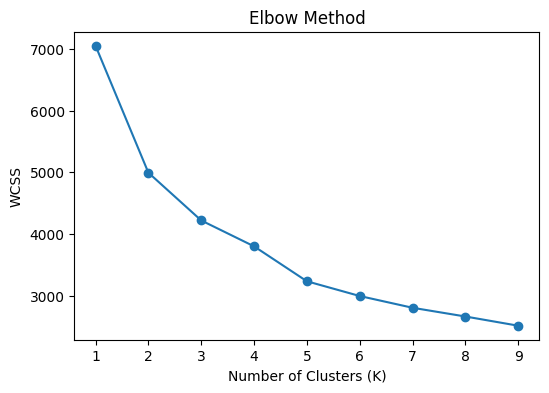

In [4]:
import matplotlib.pyplot as plt

wcss = []

# Try different K values
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot Elbow Graph
plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

results = {}

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)

    results[k] = {
        "Silhouette Score": sil_score,
        "Davies-Bouldin Index": db_score,
        "Calinski-Harabasz Index": ch_score
    }

# Print results properly
for k, metrics in results.items():
    print(f"\nK = {k}")
    for name, value in metrics.items():
        print(f"{name}: {value:.3f}")


K = 2
Silhouette Score: 0.266
Davies-Bouldin Index: 1.411
Calinski-Harabasz Index: 725.662

K = 3
Silhouette Score: 0.218
Davies-Bouldin Index: 1.445
Calinski-Harabasz Index: 590.527


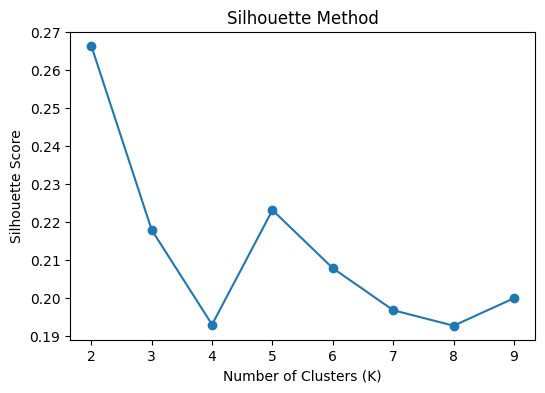

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []

# Try different K values (start from 2, since silhouette needs ≥2 clusters)
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot graph
plt.figure(figsize=(6,4))
plt.plot(K_range, sil_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')

plt.show()

In [7]:
import pandas as pd

results_df = pd.DataFrame(results).T
print(results_df)

   Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
2           0.26645               1.41067               725.661525
3           0.21800               1.44451               590.526564


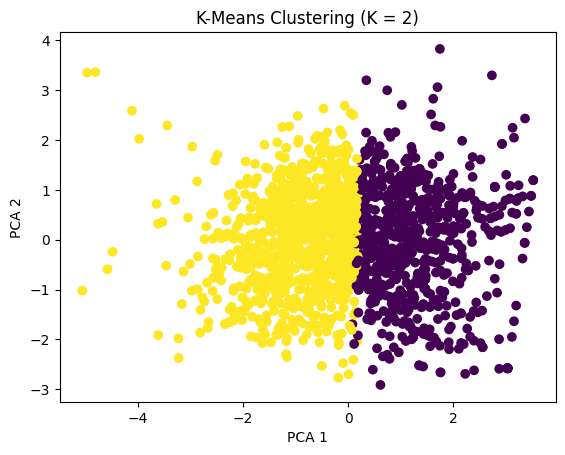

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K = 2
kmeans2 = KMeans(n_clusters=2, random_state=42)
labels2 = kmeans2.fit_predict(X_scaled)

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels2)
plt.title("K-Means Clustering (K = 2)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

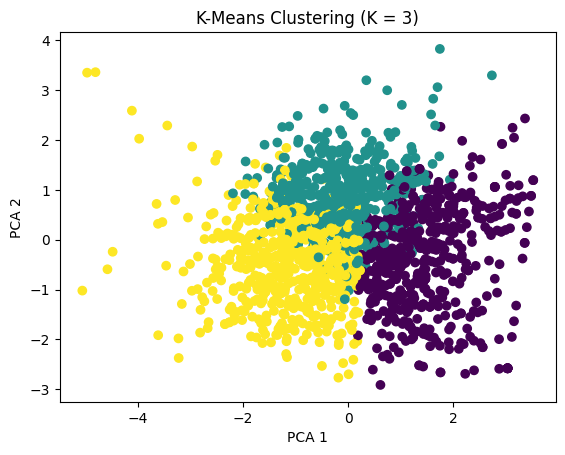

In [9]:
# K = 3
kmeans3 = KMeans(n_clusters=3, random_state=42)
labels3 = kmeans3.fit_predict(X_scaled)

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels3)
plt.title("K-Means Clustering (K = 3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

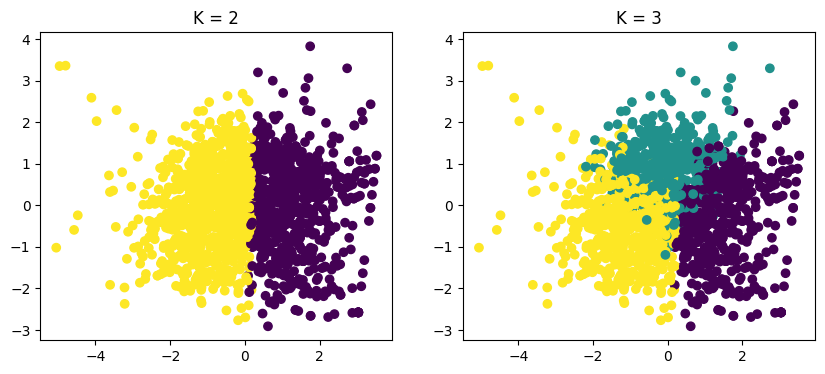

In [10]:
plt.figure(figsize=(10,4))

# K = 2
plt.subplot(1,2,1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels2)
plt.title("K = 2")

# K = 3
plt.subplot(1,2,2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels3)
plt.title("K = 3")

plt.show()

In [11]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [12]:
# Mean values of F1–F4 per cluster
cluster_means = df.groupby('Cluster')[['F1', 'F2', 'F3', 'F4']].mean()

print("\nMean Stress Levels for Each Cluster:")
print(cluster_means)


Mean Stress Levels for Each Cluster:
               F1        F2        F3        F4
Cluster                                        
0        4.256716  4.153236  2.581502  4.017399
1        3.721777  3.728791  3.032565  2.236473
2        3.140204  2.830084  2.400070  2.963788


In [13]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and predict cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters

# View first 5 rows with cluster labels
print(df.head())

         F1        F2    F3   F4  gender marital_status academic_year  \
0  3.333333  4.000000  3.00  2.5  Female         Single        Year 4   
1  3.000000  3.666667  2.75  2.0  Female         Single        Year 4   
2  3.500000  2.000000  2.00  2.0  Female         Single        Year 4   
3  3.000000  3.000000  2.50  3.0    Male         Single        Year 4   
4  3.833333  4.333333  1.50  4.0    Male         Single        Year 4   

  academic_failure age_group                              degree_program  \
0            Never     22-23         B.B.A. (Hons) in Business Economics   
1            Never     22-23     B.B.A. (Hons) in International Business   
2            Never     22-23  B.B.A. (Hons) in Human Resource Management   
3    Once or twice     22-23         B.B.A. (Hons) in Business Economics   
4            Never     22-23         B.B.A. (Hons) in Business Economics   

  faculty_environment home_environment  Cluster  
0           Satisfied              Yes        1  
1   

In [14]:
final_dataset = df[['Cluster', 'gender', 'academic_year','age_group','marital_status',
                    'degree_program', 'home_environment','academic_failure',
                    'faculty_environment','F1','F2','F3','F4']]

final_dataset.to_csv('Student_Stress_Cluster_Analysis.csv', index=False)
from google.colab import files
files.download('Student_Stress_Cluster_Analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
cluster_profile = df.groupby('Cluster')[['F1','F2','F3','F4']].mean()
print(cluster_profile)

               F1        F2        F3        F4
Cluster                                        
0        4.256716  4.153236  2.581502  4.017399
1        3.721777  3.728791  3.032565  2.236473
2        3.140204  2.830084  2.400070  2.963788


Heirachial Clsutering

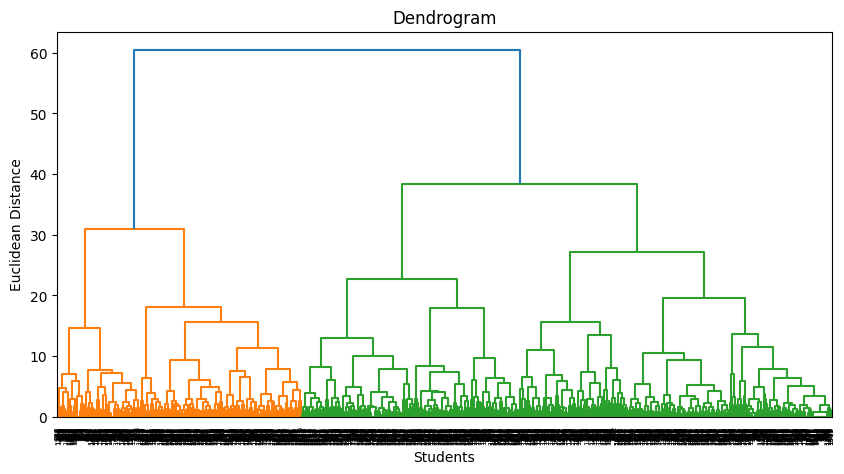

In [15]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title('Dendrogram')
plt.xlabel('Students')
plt.ylabel('Euclidean Distance')
plt.show()

In [16]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df['Hierarchical_Cluster']

sil_score = silhouette_score(X_scaled, labels)
db_score = davies_bouldin_score(X_scaled, labels)
ch_score = calinski_harabasz_score(X_scaled, labels)

print("Hierarchical Clustering Evaluation:")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Hierarchical Clustering Evaluation:
Silhouette Score: 0.187
Davies-Bouldin Index: 1.606
Calinski-Harabasz Index: 501.407


In [18]:
final_dataset = df[['gender', 'academic_year','age_group',
                    'degree_program', 'home_environment','academic_failure',
                    'faculty_environment','F1','F2','F3','F4']]

final_dataset.to_csv('Predictions_Dataset.csv', index=False)
from google.colab import files
files.download('Predictions_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>